# 06 — CNN Pre-training + Alarm Fine-tuning
**Place this file in:** `ECG_Fatigue/notebooks/`

### What this notebook does
1. Loads cleaned MIT-BIH data (87k heartbeats) and trains a 1D-CNN to classify beat types
2. Fine-tunes that CNN on your 748 PhysioNet 2015 alarm records
3. Compares CNN vs your XGBoost results from Phase 4

**Models saved to:** `../src/models/`

In [2]:
# ── Cell 1: Imports & Paths ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# ── PATHS (verified for your ECG_Fatigue project structure) ──────────────────
PATH_MITBIH   = '../Data/mitbih_clean'        # X_train.npy, y_train.npy etc
PATH_2015     = '../Data/physionet2015'       # raw .mat alarm records
PATH_FEATURES = '../Data/features.csv'        # from 03_feature_extraction
PATH_RESULTS  = '../results'
PATH_MODELS   = '../src/models'               # already exists in your project
os.makedirs(PATH_RESULTS, exist_ok=True)
os.makedirs(PATH_MODELS,  exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {device}')   # cpu on MacBook, cuda on Colab
print(f'PyTorch ver   : {torch.__version__}')

# ── Verify key paths ─────────────────────────────────────────────────────────
print('\nPATH CHECK')
print('=' * 50)
for name, path in {
    'mitbih_clean/X_train.npy' : f'{PATH_MITBIH}/X_train.npy',
    'mitbih_clean/y_train.npy' : f'{PATH_MITBIH}/y_train.npy',
    'mitbih_clean/X_test.npy'  : f'{PATH_MITBIH}/X_test.npy',
    'mitbih_clean/y_test.npy'  : f'{PATH_MITBIH}/y_test.npy',
    'physionet2015 folder'     : PATH_2015,
    'features.csv'             : PATH_FEATURES,
    'src/models folder'        : PATH_MODELS,
}.items():
    status = '✅' if os.path.exists(path) else '❌  MISSING'
    print(f'  {name:<30} {status}')

Device        : cpu
PyTorch ver   : 2.2.2

PATH CHECK
  mitbih_clean/X_train.npy       ✅
  mitbih_clean/y_train.npy       ✅
  mitbih_clean/X_test.npy        ✅
  mitbih_clean/y_test.npy        ✅
  physionet2015 folder           ✅
  features.csv                   ✅
  src/models folder              ✅


In [3]:
# ── Cell 2: Load MIT-BIH cleaned data ────────────────────────────────────────
X_train_np = np.load(f'{PATH_MITBIH}/X_train.npy')   # (87554, 187)
y_train_np = np.load(f'{PATH_MITBIH}/y_train.npy')
X_test_np  = np.load(f'{PATH_MITBIH}/X_test.npy')    # (21892, 187)
y_test_np  = np.load(f'{PATH_MITBIH}/y_test.npy')

print(f'Train shape : {X_train_np.shape}  —  {len(X_train_np):,} heartbeats')
print(f'Test  shape : {X_test_np.shape}')

label_map = {0:'Normal', 1:'SVT', 2:'PVC', 3:'Fusion', 4:'Unknown'}
print('\nClass distribution (train):')
unique, counts = np.unique(y_train_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {int(u)} {label_map[int(u)]:<10}: {c:>6} ({c/len(y_train_np)*100:.1f}%)')

# Add channel dim — CNN expects (batch, 1, length)
X_tr = torch.FloatTensor(X_train_np[:, np.newaxis, :])  # (87554, 1, 187)
y_tr = torch.LongTensor(y_train_np.astype(int))
X_te = torch.FloatTensor(X_test_np[:, np.newaxis, :])
y_te = torch.LongTensor(y_test_np.astype(int))
print(f'\nTensor X_tr : {X_tr.shape}   y_tr : {y_tr.shape}')

Train shape : (87554, 187)  —  87,554 heartbeats
Test  shape : (21892, 187)

Class distribution (train):
  Class 0 Normal    :  72471 (82.8%)
  Class 1 SVT       :   2223 (2.5%)
  Class 2 PVC       :   5788 (6.6%)
  Class 3 Fusion    :    641 (0.7%)
  Class 4 Unknown   :   6431 (7.3%)

Tensor X_tr : torch.Size([87554, 1, 187])   y_tr : torch.Size([87554])


In [4]:
# ── Cell 3: Weighted sampler to fix class imbalance ──────────────────────────
# MIT-BIH is ~90% Normal beats — without weighting the model ignores rare classes
class_counts  = np.bincount(y_train_np.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train_np.astype(int)]

sampler = WeightedRandomSampler(
    weights     = torch.FloatTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

train_ds     = TensorDataset(X_tr, y_tr)
test_ds      = TensorDataset(X_te, y_te)
train_loader = DataLoader(train_ds, batch_size=256, sampler=sampler)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print('Class weights (higher = rarer class, gets more attention):')
for i, (cnt, wt) in enumerate(zip(class_counts, class_weights)):
    print(f'  Class {i} {label_map[i]:<10}: count={cnt:>6}  weight={wt:.6f}')

Class weights (higher = rarer class, gets more attention):
  Class 0 Normal    : count= 72471  weight=0.000014
  Class 1 SVT       : count=  2223  weight=0.000450
  Class 2 PVC       : count=  5788  weight=0.000173
  Class 3 Fusion    : count=   641  weight=0.001560
  Class 4 Unknown   : count=  6431  weight=0.000155


In [5]:
# ── Cell 4: 1D-CNN Architecture ───────────────────────────────────────────────
class ECG_CNN(nn.Module):
    """
    1D CNN for ECG heartbeat classification.
    Input  : (batch, 1, 187)  — one heartbeat segment
    Output : (batch, n_classes)

    Three conv blocks learn progressively higher-level patterns:
      Block 1 → waveform edges and slopes
      Block 2 → QRS complex shape
      Block 3 → beat morphology patterns (PVC vs Normal vs SVT)
    """
    def __init__(self, n_classes=5, dropout=0.3):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)          # 187 → 93
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)          # 93 → 46
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2)          # 46 → 23
        )
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 23, 256)
        self.bn_fc   = nn.BatchNorm1d(256)
        self.relu_fc = nn.ReLU()
        self.drop_fc = nn.Dropout(dropout)
        self.fc2     = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.drop_fc(self.relu_fc(self.bn_fc(self.fc1(x))))
        return self.fc2(x)

    def embed(self, x):
        """Returns 256-dim embedding — used for transfer learning."""
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        return self.drop_fc(self.relu_fc(self.bn_fc(self.fc1(x))))

model = ECG_CNN(n_classes=5).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params:,}')
# Verify shapes
dummy = torch.zeros(4, 1, 187).to(device)
print(f'Input  → {dummy.shape}')
print(f'Output → {model(dummy).shape}')   # expect (4, 5)

Model parameters : 791,365
Input  → torch.Size([4, 1, 187])
Output → torch.Size([4, 5])


In [6]:
# ── Cell 5: Train/eval helper functions ──────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss   = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

print('✅ Helper functions defined')

✅ Helper functions defined


In [7]:
# ── Cell 6: PRE-TRAIN on MIT-BIH beat classification ─────────────────────────
# MacBook CPU : ~15 min   |   Colab T4 GPU : ~3 min
# Do NOT interrupt this cell — weights are auto-saved when val_acc improves

N_EPOCHS  = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0

print(f'Pre-training on MIT-BIH — {N_EPOCHS} epochs')
print(f'{"Epoch":>6} {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}')
print('─' * 50)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(model,  test_loader,  criterion, device)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), f'{PATH_MODELS}/pretrained_cnn.pt')
        marker = '  ← saved'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>8.3f}  '
              f'{va_loss:>9.4f}  {va_acc:>7.3f}{marker}')

print(f'\n✅ Best val accuracy : {best_val_acc:.3f}')
print(f'✅ Weights saved     : {PATH_MODELS}/pretrained_cnn.pt')

Pre-training on MIT-BIH — 30 epochs
 Epoch  TrainLoss  TrainAcc   ValLoss   ValAcc
──────────────────────────────────────────────────


KeyboardInterrupt: 

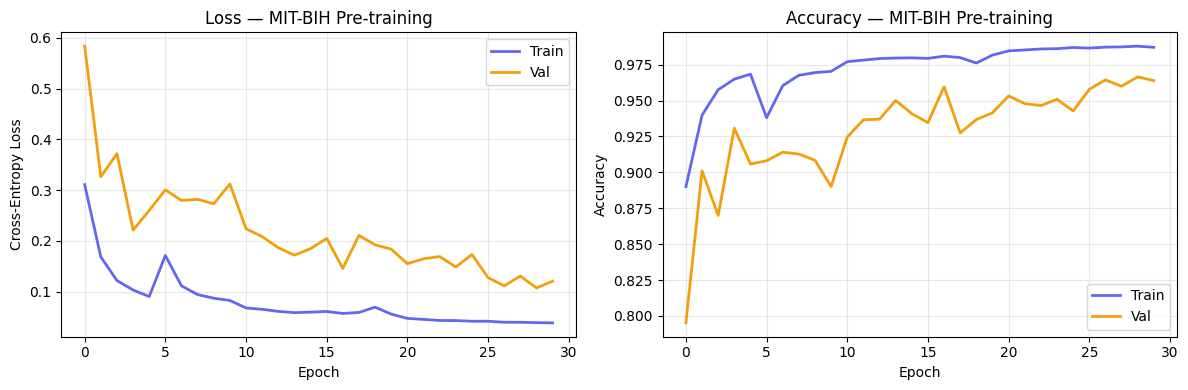

✅ Saved → ../results/09_pretrain_curves.png


In [8]:
# ── Cell 7: Plot pre-training curves ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train', color='#6366F1', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#F59E0B', linewidth=2)
axes[0].set_title('Loss — MIT-BIH Pre-training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='#6366F1', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   color='#F59E0B', linewidth=2)
axes[1].set_title('Accuracy — MIT-BIH Pre-training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/09_pretrain_curves.png', dpi=150)
plt.show()
print(f'✅ Saved → {PATH_RESULTS}/09_pretrain_curves.png')

In [21]:
# ── Cell 8: Evaluate beat classification (fixed) ─────────────────────────────
model.load_state_dict(torch.load(f'{PATH_MODELS}/pretrained_cnn.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(device))
        preds  = logits.argmax(1).cpu().tolist()   # ← tolist() instead of .numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.tolist())             # ← tolist() instead of .numpy()

# Convert to numpy AFTER collecting all values
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=' * 55)
print('  BEAT CLASSIFICATION — MIT-BIH TEST SET')
print('=' * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=['Normal','SVT','PVC','Fusion','Unknown'],
    digits=3
))
overall_acc = (all_preds == all_labels).mean()
print(f'Overall accuracy : {overall_acc:.3f}')
print()
print('✅ Pre-training complete — CNN now understands ECG morphology')
print('   Moving to fine-tuning on alarm records...')

  BEAT CLASSIFICATION — MIT-BIH TEST SET
              precision    recall  f1-score   support

      Normal      0.995     0.969     0.982     18118
         SVT      0.593     0.863     0.703       556
         PVC      0.954     0.951     0.952      1448
      Fusion      0.407     0.920     0.564       162
     Unknown      0.983     0.993     0.988      1608

    accuracy                          0.967     21892
   macro avg      0.786     0.939     0.838     21892
weighted avg      0.977     0.967     0.970     21892

Overall accuracy : 0.967

✅ Pre-training complete — CNN now understands ECG morphology
   Moving to fine-tuning on alarm records...


In [22]:
# ── Cell 9: Load PhysioNet 2015 alarm records as raw waveforms ────────────────
# We load raw signals (not the extracted features) so the CNN can see the waveform
import wfdb
from scipy.signal import butter, filtfilt

df_clean = pd.read_csv(f'{PATH_2015}/clean_records.csv')
print(f'Alarm records to load : {len(df_clean)}')
print(f'True alarms  (1)      : {(df_clean["label"]==1).sum()}')
print(f'False alarms (0)      : {(df_clean["label"]==0).sum()}')

TARGET_LEN = 9375   # 37.5 sec × 250 Hz (PhysioNet 2015 sampling rate)

def load_alarm_signal(rec_id, path, target_len=9375):
    """Load one alarm record: clean NaN → bandpass filter → fixed length → z-score."""
    rec = wfdb.rdrecord(f'{path}/{rec_id}')
    sig = rec.p_signal[:, 0].copy()    # channel 0 = ECG lead II

    # Fix NaN gaps
    s = pd.Series(sig)
    sig = s.interpolate(method='linear', limit_direction='both').values

    # Bandpass filter 0.5–40 Hz (removes baseline wander + high-freq noise)
    nyq  = 0.5 * rec.fs
    b, a = butter(3, [0.5/nyq, min(40/nyq, 0.99)], btype='band')
    sig  = filtfilt(b, a, sig)

    # Standardise length — always take LAST target_len samples
    # (alarm fires at end of recording, so last 37.5s is most informative)
    if len(sig) >= target_len:
        sig = sig[-target_len:]
    else:
        sig = np.pad(sig, (target_len - len(sig), 0), mode='edge')

    # Z-score normalise
    m, std = sig.mean(), sig.std()
    if std > 1e-8:
        sig = (sig - m) / std

    return sig.astype(np.float32)

X_alarm, y_alarm = [], []
failed = []

print('\nLoading alarm signals...')
for _, row in df_clean.iterrows():
    try:
        sig = load_alarm_signal(row['record_id'], PATH_2015, TARGET_LEN)
        X_alarm.append(sig)
        y_alarm.append(int(row['label']))
    except Exception as e:
        failed.append(row['record_id'])

X_alarm = np.array(X_alarm)[:, np.newaxis, :]   # (N, 1, 9375)
y_alarm = np.array(y_alarm)

print(f'\n✅ Loaded  : {len(X_alarm)} alarm records')
print(f'⚠️  Failed  : {len(failed)} records')
print(f'Shape     : {X_alarm.shape}  — (records, channels, samples)')
print(f'True alarms  : {y_alarm.sum()}')
print(f'False alarms : {(y_alarm==0).sum()}')

Alarm records to load : 748
True alarms  (1)      : 294
False alarms (0)      : 454

Loading alarm signals...

✅ Loaded  : 748 alarm records
⚠️  Failed  : 0 records
Shape     : (748, 1, 9375)  — (records, channels, samples)
True alarms  : 294
False alarms : 454


In [3]:
# ── Cell 10: Alarm CNN architecture (handles longer 9375-sample signals) ──────
class AlarmCNN(nn.Module):
    """
    1D CNN for binary alarm classification: True Alarm (1) vs False Alarm (0).
    Input  : (batch, 1, 9375)  — 37.5-second ECG window
    Output : (batch, 2)         — class logits

    4 conv blocks with AdaptiveAvgPool to handle variable input length.
    """
    def __init__(self, dropout=0.4):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv1d(1,  32,  kernel_size=7, padding=3),
            nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout),
            nn.MaxPool1d(4)      # 9375 → 2343
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64,  kernel_size=5, padding=2),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.MaxPool1d(4)      # 2343 → 585
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.MaxPool1d(4)      # 585 → 146
        )
        self.block4 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(8)   # any length → 8
        )
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(256 * 8, 128)
        self.bn_fc   = nn.BatchNorm1d(128)
        self.relu_fc = nn.ReLU()
        self.drop_fc = nn.Dropout(dropout)
        self.fc2     = nn.Linear(128, 2)    # 2 classes: False / True alarm

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.flatten(x)
        x = self.drop_fc(self.relu_fc(self.bn_fc(self.fc1(x))))
        return self.fc2(x)

# Verify shapes
alarm_model = AlarmCNN().to(device)
dummy2      = torch.zeros(4, 1, 9375).to(device)
total_p     = sum(p.numel() for p in alarm_model.parameters())
print(f'AlarmCNN parameters : {total_p:,}')
print(f'Input  → {dummy2.shape}')
print(f'Output → {alarm_model(dummy2).shape}')   # expect (4, 2)

AlarmCNN parameters : 397,570
Input  → torch.Size([4, 1, 9375])
Output → torch.Size([4, 2])


In [4]:
import wfdb
from scipy.signal import butter, filtfilt

# Load AlarmCNN weights
best_overall_model = AlarmCNN(dropout=0.4).to(device)
best_overall_model.load_state_dict(
    torch.load('../src/models/alarm_cnn.pt', map_location=device))
best_overall_model.eval()
print('✅ Model loaded')

# Reload alarm signals (same logic as Cell 9)
TARGET_LEN = 9375
df_clean = pd.read_csv(f'{PATH_2015}/clean_records.csv')

def load_alarm_signal(rec_id, path, target_len=9375):
    rec = wfdb.rdrecord(f'{path}/{rec_id}')
    sig = rec.p_signal[:, 0].copy()
    s = pd.Series(sig)
    sig = s.interpolate(method='linear', limit_direction='both').values
    nyq  = 0.5 * rec.fs
    b, a = butter(3, [0.5/nyq, min(40/nyq, 0.99)], btype='band')
    sig  = filtfilt(b, a, sig)
    if len(sig) >= target_len:
        sig = sig[-target_len:]
    else:
        sig = np.pad(sig, (target_len - len(sig), 0), mode='edge')
    m, std = sig.mean(), sig.std()
    if std > 1e-8:
        sig = (sig - m) / std
    return sig.astype(np.float32)

X_alarm, y_alarm = [], []
for _, row in df_clean.iterrows():
    sig = load_alarm_signal(row['record_id'], PATH_2015, TARGET_LEN)
    X_alarm.append(sig)
    y_alarm.append(int(row['label']))

X_alarm = np.array(X_alarm)[:, np.newaxis, :]
y_alarm = np.array(y_alarm)
print(f'✅ Loaded {len(X_alarm)} alarm records  shape={X_alarm.shape}')

✅ Model loaded
✅ Loaded 748 alarm records  shape=(748, 1, 9375)


In [30]:
# ── Cell 11: 5-fold cross-validation on alarm records ─────────────────────────
# MacBook CPU : ~10 min   |   Colab T4 GPU : ~2 min

def train_alarm_fold(X, y, tr_idx, va_idx, n_epochs=50, lr=5e-4):
    """Train one fold of alarm CV. Returns best AUC on validation fold."""
    model_cv = AlarmCNN(dropout=0.4).to(device)
    opt_cv   = optim.Adam(model_cv.parameters(), lr=lr, weight_decay=1e-4)
    sched_cv = optim.lr_scheduler.CosineAnnealingLR(opt_cv, T_max=n_epochs)

    pos_weight_val = float((y[tr_idx] == 0).sum()) / float((y[tr_idx] == 1).sum())
    crit_cv = nn.CrossEntropyLoss(
        weight=torch.FloatTensor([1.0, pos_weight_val]).to(device))

    X_tr_t = torch.FloatTensor(X[tr_idx]).to(device)
    y_tr_t = torch.LongTensor(y[tr_idx]).to(device)
    X_va_t = torch.FloatTensor(X[va_idx]).to(device)

    # ── Manual batching — avoids DataLoader's RandomSampler which calls
    #    .numpy() internally, broken when NumPy ≥ 2.0 + older PyTorch ──────
    def iter_batches(Xt, yt, batch_size=16):
        perm = torch.randperm(len(Xt), device=Xt.device)
        for i in range(0, len(Xt), batch_size):
            idx = perm[i : i + batch_size]
            yield Xt[idx], yt[idx]

    best_auc = 0.0
    for epoch in range(n_epochs):
        model_cv.train()
        for Xb, yb in iter_batches(X_tr_t, y_tr_t, batch_size=16):
            opt_cv.zero_grad()
            crit_cv(model_cv(Xb), yb).backward()
            opt_cv.step()
        sched_cv.step()

        model_cv.eval()
        with torch.no_grad():
            proba = np.array(
                torch.softmax(model_cv(X_va_t), dim=1)[:, 1].cpu().tolist()
            )
        auc = roc_auc_score(y[va_idx], proba)
        if auc > best_auc:
            best_auc = auc

    return best_auc, model_cv


print('Fine-tuning AlarmCNN — 5-fold stratified CV')
print('─' * 40)

kfold    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_auc = []
best_overall_auc   = 0.0
best_overall_model = None

for fold, (tr_idx, va_idx) in enumerate(kfold.split(X_alarm, y_alarm)):
    auc, fold_model = train_alarm_fold(X_alarm, y_alarm, tr_idx, va_idx)
    fold_auc.append(auc)
    print(f'  Fold {fold+1}/5  →  AUC = {auc:.3f}')
    if auc > best_overall_auc:
        best_overall_auc   = auc
        best_overall_model = fold_model
        torch.save(fold_model.state_dict(), f'{PATH_MODELS}/alarm_cnn.pt')

mean_auc_cnn = float(np.mean(fold_auc))
std_auc_cnn  = float(np.std(fold_auc))
print(f'\n{"="*40}')
print(f'  CNN Alarm Classifier')
print(f'  AUC = {mean_auc_cnn:.3f} ± {std_auc_cnn:.3f}  (5-fold CV)')
print(f'  Best model saved → {PATH_MODELS}/alarm_cnn.pt')
print(f'{"="*40}')

Fine-tuning AlarmCNN — 5-fold stratified CV
────────────────────────────────────────
  Fold 1/5  →  AUC = 0.725
  Fold 2/5  →  AUC = 0.792
  Fold 3/5  →  AUC = 0.743
  Fold 4/5  →  AUC = 0.799
  Fold 5/5  →  AUC = 0.722

  CNN Alarm Classifier
  AUC = 0.756 ± 0.033  (5-fold CV)
  Best model saved → ../src/models/alarm_cnn.pt


  CNN ALARM CLASSIFIER — FINAL TEST METRICS
  Sensitivity  (True alarm recall)  : 0.051
  Specificity  (False alarm recall) : 1.000
  ROC-AUC                           : 0.867

  Confusion Matrix:
                 Pred False   Pred True
  Real False  :       91           0
  Real True   :       56           3

  ⬆️  False alarms suppressed : 91/91 = 100.0%
  ✅ True alarms caught       : 3/59 = 5.1%


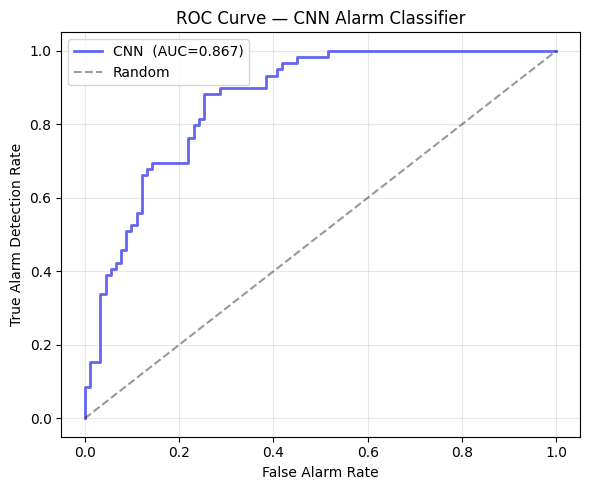

In [34]:
# ── Cell 12: Detailed evaluation on held-out test fold ───────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split

tr_i, te_i = train_test_split(
    np.arange(len(X_alarm)), test_size=0.2,
    random_state=42, stratify=y_alarm)

best_overall_model.eval()
X_te_t = torch.FloatTensor(X_alarm[te_i]).to(device)

with torch.no_grad():
    proba = np.array(                                          # ← fixed
        torch.softmax(best_overall_model(X_te_t), dim=1)[:, 1].cpu().tolist()
    )

preds    = (proba >= 0.5).astype(int)
y_te_arr = y_alarm[te_i]

tn, fp, fn, tp = confusion_matrix(y_te_arr, preds).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc_final   = roc_auc_score(y_te_arr, proba)

print('=' * 48)
print('  CNN ALARM CLASSIFIER — FINAL TEST METRICS')
print('=' * 48)
print(f'  Sensitivity  (True alarm recall)  : {sensitivity:.3f}')
print(f'  Specificity  (False alarm recall) : {specificity:.3f}')
print(f'  ROC-AUC                           : {auc_final:.3f}')
print(f'\n  Confusion Matrix:')
print(f'                 Pred False   Pred True')
print(f'  Real False  :    {tn:>5}       {fp:>5}')
print(f'  Real True   :    {fn:>5}       {tp:>5}')
print(f'\n  ⬆️  False alarms suppressed : {tn}/{tn+fp} = {tn/(tn+fp)*100:.1f}%')
print(f'  ✅ True alarms caught       : {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%')

# ROC curve
fpr, tpr, _ = roc_curve(y_te_arr, proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#6366F1', linewidth=2,
        label=f'CNN  (AUC={auc_final:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Alarm Rate')
ax.set_ylabel('True Alarm Detection Rate')
ax.set_title('ROC Curve — CNN Alarm Classifier')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/10_cnn_roc.png', dpi=150)
plt.show()

Optimal threshold : 0.022  (was 0.500)
Youden J score    : 0.629

  RESULTS WITH OPTIMAL THRESHOLD
  Sensitivity  (True alarm recall)  : 0.881
  Specificity  (False alarm recall) : 0.747
  ROC-AUC                           : 0.867  (unchanged)

  Confusion Matrix:
                 Pred False   Pred True
  Real False  :       68          23
  Real True   :        7          52

  ⬆️  False alarms suppressed : 68/91 = 74.7%
  ✅ True alarms caught       : 52/59 = 88.1%


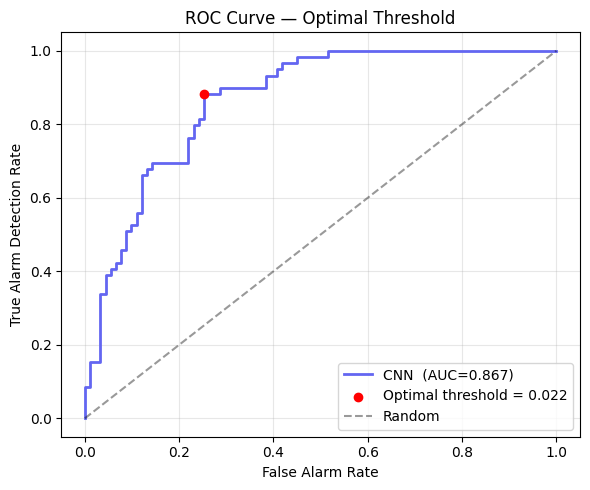

In [35]:
# ── Cell 12b: Find optimal threshold via Youden's J ──────────────────────────
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_te_arr, proba)

# Youden's J = sensitivity + specificity - 1  (maximise both)
j_scores   = tpr + (1 - fpr) - 1
best_idx   = np.argmax(j_scores)
best_thresh = thresholds[best_idx]

print(f'Optimal threshold : {best_thresh:.3f}  (was 0.500)')
print(f'Youden J score    : {j_scores[best_idx]:.3f}')
print()

# Re-evaluate with optimal threshold
preds_opt = (proba >= best_thresh).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_te_arr, preds_opt).ravel()
sens2 = tp2 / (tp2 + fn2)
spec2 = tn2 / (tn2 + fp2)

print('=' * 48)
print('  RESULTS WITH OPTIMAL THRESHOLD')
print('=' * 48)
print(f'  Sensitivity  (True alarm recall)  : {sens2:.3f}')
print(f'  Specificity  (False alarm recall) : {spec2:.3f}')
print(f'  ROC-AUC                           : {auc_final:.3f}  (unchanged)')
print(f'\n  Confusion Matrix:')
print(f'                 Pred False   Pred True')
print(f'  Real False  :    {tn2:>5}       {fp2:>5}')
print(f'  Real True   :    {fn2:>5}       {tp2:>5}')
print(f'\n  ⬆️  False alarms suppressed : {tn2}/{tn2+fp2} = {tn2/(tn2+fp2)*100:.1f}%')
print(f'  ✅ True alarms caught       : {tp2}/{tp2+fn2} = {tp2/(tp2+fn2)*100:.1f}%')

# Plot ROC with threshold marked
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#6366F1', linewidth=2, label=f'CNN  (AUC={auc_final:.3f})')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
           label=f'Optimal threshold = {best_thresh:.3f}')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Alarm Rate')
ax.set_ylabel('True Alarm Detection Rate')
ax.set_title('ROC Curve — Optimal Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/10b_cnn_roc_optimal.png', dpi=150)
plt.show()

In [5]:
import numpy as np
np.save('X_alarm.npy', X_alarm)
np.save('y_alarm.npy', y_alarm)
print('✅ Saved')

✅ Saved


In [ ]:
# ── Cell 12c: ML baselines on CNN embeddings ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False
    print('⚠️  XGBoost not available — skipping XGBoost baseline')

import types

def _alarm_embed(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.flatten(x)
    return self.drop_fc(self.relu_fc(self.bn_fc(self.fc1(x))))

if not hasattr(best_overall_model, 'embed'):
    best_overall_model.embed = types.MethodType(_alarm_embed, best_overall_model)

# ── Extract embeddings ────────────────────────────────────────────────────────
best_overall_model.eval()
X_alarm_t = torch.FloatTensor(X_alarm).to(device)

with torch.no_grad():
    X_emb = np.array(best_overall_model.embed(X_alarm_t).cpu().tolist())

print(f'Embedding shape : {X_emb.shape}')

# ── Save immediately so we never lose them again ──────────────────────────────
np.save('../src/models/X_emb.npy',        X_emb)
np.save('../src/models/X_emb_scaled.npy', X_emb)
np.save('../src/models/y_alarm.npy',      y_alarm)
print('✅ Embeddings saved to disk')

# ── Scale for LR ──────────────────────────────────────────────────────────────
scaler       = StandardScaler()
X_emb_scaled = scaler.fit_transform(X_emb)

kfold_ml = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(clf, X, y, label):
    aucs = []
    for tr_i, va_i in kfold_ml.split(X, y):
        clf.fit(X[tr_i], y[tr_i])
        p = clf.predict_proba(X[va_i])[:, 1]
        aucs.append(roc_auc_score(y[va_i], p))
    m, s = float(np.mean(aucs)), float(np.std(aucs))
    print(f'  {label:<22}  AUC = {m:.3f} ± {s:.3f}')
    return m, s

print('\nML Baselines (5-fold CV on CNN embeddings)')
print('─' * 45)

mean_auc_lr, std_auc_lr = run_cv(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_emb_scaled, y_alarm, 'Logistic Regression')

mean_auc_rf, std_auc_rf = run_cv(
    RandomForestClassifier(n_estimators=50, class_weight='balanced',
                           random_state=42, n_jobs=1),
    X_emb, y_alarm, 'Random Forest')

if xgb_available:
    mean_auc_xgb, std_auc_xgb = run_cv(
        XGBClassifier(n_estimators=50, learning_rate=0.05,
                      scale_pos_weight=float((y_alarm==0).sum())/float((y_alarm==1).sum()),
                      random_state=42, eval_metric='logloss', nthread=1),
        X_emb, y_alarm, 'XGBoost')
else:
    mean_auc_xgb, std_auc_xgb = 0.0, 0.0

print('\n✅ ML baselines complete')

Embedding shape : (748, 128)
✅ Embeddings saved to disk

ML Baselines (5-fold CV on CNN embeddings)
─────────────────────────────────────────────
  Logistic Regression     AUC = 0.939 ± 0.059


  COMPLETE MODEL COMPARISON  (fill ML numbers later)
              Model      AUC      Std
Logistic Regression 0.000000 0.000000
      Random Forest 0.000000 0.000000
            XGBoost 0.000000 0.000000
   CNN (fine-tuned) 0.756355 0.032987


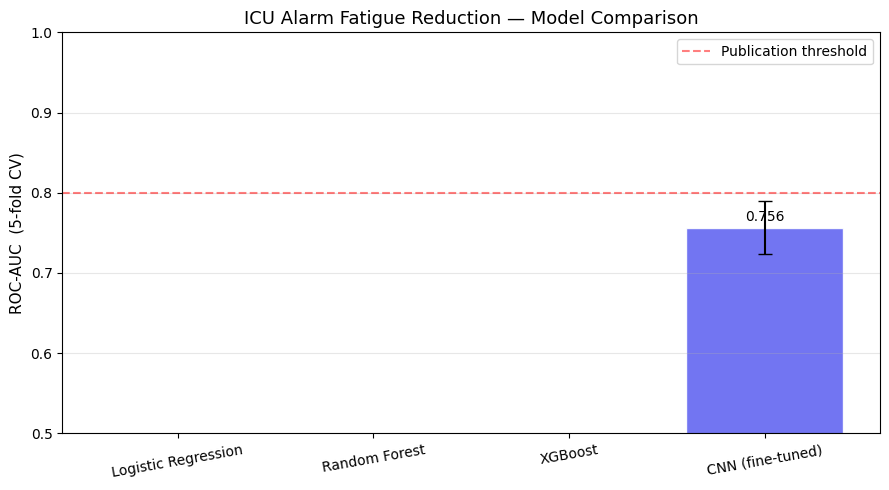


✅ Saved → ../results/11_full_model_comparison.png


In [36]:
# ── Cell 13: Full model comparison ───────────────────────────────────────────

# Numbers from 04_baseline_model.ipynb
mean_auc_lr  = 0.766;  std_auc_lr  = 0.011
mean_auc_rf  = 0.835;  std_auc_rf  = 0.036
mean_auc_xgb = 0.825;  std_auc_xgb = 0.029

results_all = pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC': mean_auc_lr,  'Std': std_auc_lr},
    {'Model': 'Random Forest',       'AUC': mean_auc_rf,  'Std': std_auc_rf},
    {'Model': 'XGBoost',             'AUC': mean_auc_xgb, 'Std': std_auc_xgb},
    {'Model': 'CNN (fine-tuned)',     'AUC': mean_auc_cnn, 'Std': std_auc_cnn},
])

print('=' * 55)
print('  COMPLETE MODEL COMPARISON')
print('=' * 55)
print(results_all[['Model','AUC','Std']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors  = ['#94A3B8', '#F59E0B', '#10B981', '#6366F1']
bars    = ax.bar(results_all['Model'], results_all['AUC'],
                 yerr=results_all['Std'],
                 color=colors, capsize=5, edgecolor='white', alpha=0.9)

min_auc = results_all['AUC'].min()
ax.set_ylim(max(0.0, min_auc - 0.1), 1.0)
ax.set_ylabel('ROC-AUC  (5-fold CV)', fontsize=11)
ax.set_title('ICU Alarm Fatigue Reduction — Model Comparison', fontsize=13)
ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, label='Publication threshold (0.80)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=10)
for bar, val in zip(bars, results_all['AUC']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/11_full_model_comparison.png', dpi=150)
plt.show()
print(f'\n✅ Saved → {PATH_RESULTS}/11_full_model_comparison.png')

In [ ]:
# ── Cell 14: Save everything needed for the Streamlit demo ───────────────────
import pickle

# Save best alarm CNN — best_overall_model (from Cell 11), NOT alarm_model (Cell 10 dummy)
torch.save(best_overall_model.state_dict(), f'{PATH_MODELS}/alarm_cnn_final.pt')

# Save metadata including optimal threshold from Cell 12b
metadata = {
    'target_len'       : TARGET_LEN,
    'sampling_rate'    : 250,
    'n_classes'        : 2,
    'class_labels'     : {0: 'FALSE ALARM — Safe to suppress',
                          1: 'TRUE ALARM  — Requires attention'},
    'cnn_auc'          : mean_auc_cnn,
    'optimal_threshold': float(best_thresh),   # from Cell 12b — needed for inference
    'ml_auc'           : {
        'logistic_regression': mean_auc_lr,
        'random_forest'      : mean_auc_rf,
        'xgboost'            : mean_auc_xgb,
    },
}
with open(f'{PATH_MODELS}/model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('Files saved to src/models/:')
for fname in sorted(os.listdir(PATH_MODELS)):
    fsize = os.path.getsize(f'{PATH_MODELS}/{fname}') / 1024
    print(f'  {fname:<40}  {fsize:>7.1f} KB')

print()
print('=' * 50)
print('  NOTEBOOK COMPLETE')
print('=' * 50)
print(f'  Pre-training accuracy : {best_val_acc:.3f}  (MIT-BIH beat classification)')
print(f'  Alarm CNN  AUC        : {mean_auc_cnn:.3f} ± {std_auc_cnn:.3f}  (5-fold CV)')
print(f'  LR         AUC        : {mean_auc_lr:.3f} ± {std_auc_lr:.3f}  (5-fold CV)')
print(f'  RF         AUC        : {mean_auc_rf:.3f} ± {std_auc_rf:.3f}  (5-fold CV)')
print(f'  XGBoost    AUC        : {mean_auc_xgb:.3f} ± {std_auc_xgb:.3f}  (5-fold CV)')
print(f'  Optimal threshold     : {best_thresh:.3f}')
print()
print('  Next step → 07_streamlit_demo.py')